# EDA практикум

# Описание датасета

Датасет подготовлен для учебной задачи Entity Resolution: необходимо определить, какие профили относятся к одному реальному человеку.

Одна строка датасета соответствует событию профиля в маркетплейсе скидок. Один и тот же профиль может встречаться в нескольких строках.

## Объём данных

В наборе 187270 уникальных профилей, соответствующих исходным `customer_id`. Из них 2654 профиля входят в `multi_profile` entity, то есть связаны с другими профилями как один реальный человек.

## Разбиение

Данные разделены на три набора:

- `train` - 60%
- `test` - 20%
- `validation` - 20%

Разбиение выполнено с учётом типа entity: `multi_profile` и `single_profile` разбивались на наборы отдельно. Все записи одной entity попадают только в один набор.


## Ключевые сущности

| Поле | Интерпретация |
|---|---|
| `profile_id` | Идентификатор профиля. |
| `entity_id` | Идентификатор реального пользователя. Несколько разных `profile_id` с одним `entity_id` считаются профилями одного пользователя. |
| `entity_type` | Тип entity: `single_profile`, если entity содержит один профиль, и `multi_profile`, если в одну entity входит несколько профилей. |

## Состав полей

| Поле | Тип | Описание |
|---|---|---|
| `created_at` | timestamp | Время события. Может использоваться для сортировки событий и построения временных признаков. |
| `first_name` | string | Анонимизированное имя. Преобразование детерминированное: одно исходное имя преобразуется одинаково. Род имени сохранён. |
| `last_name` | string | Анонимизированная фамилия. Преобразование детерминированное, род фамилии сохранён. |
| `email` | string | Анонимизированный email. Локальная часть до `@` заменена синтетически, домен оставлен без изменений. Это позволяет использовать признаки домена. |
| `phone` | string | Анонимизированный телефон. Сохранены код страны и первые 3 цифры кода оператора. Остальные цифры заменены детерминированно. |
| `birthday` | date | Анонимизированная дата рождения. Даты 1 января оставлены без изменения. |
| `sex` | string | Пол из исходного профиля, если он был указан. Может быть пустым. |
| `non_processing_features` | array<string> | Набор технических и контекстных признаков события в формате строк. Например: устройство, браузер, ОС, географические признаки. |
| `realtime_features` | string | JSON-строка с признаками, рассчитанными в момент события. Например: количество визитов, страна, город, локальный час, день недели. |
| `fs_features` | array<string> | Исторические признаки профиля из feature store. Формат элемента: `feature_name:value` или флаг без значения, например `is_gmail`. |
| `profile_id` | string | Идентификатор профиля. |
| `entity_id` | string | Идентификатор entity. |
| `entity_type` | string | Тип entity: `single_profile` или `multi_profile`. |

`entity_id` является целевой разметкой для задачи Entity Resolution.

## Как читать `fs_features`

`fs_features` - это массив строк. Каждый элемент описывает один бинарный или категориальный признак.

Примеры:

- `visited_365:1640` - профиль посещал сайт с замаскированным id `1640` за последние 365 дней.
- `visited_30:3130` - профиль посещал сайт с замаскированным id `3130` за последние 30 дней.
- `source_site_365:3768` - за последние 365 дней у профиля встречался source site с замаскированным id `3768`.
- `has_account:2046` - у профиля есть аккаунт на сайте с замаскированным id `2046`.
- `is_man` - флаг без дополнительного значения.
- `postman_response_90:ok` - категориальный признак email-коммуникации за последние 90 дней.

Числовые значения в site-признаках являются замаскированными site id.

## Site-id признаки в `fs_features`

У следующих признаков значение после `:` является замаскированным site id:

- `has_accept_30`
- `has_accept_365`
- `has_account`
- `has_click_30`
- `has_click_365`
- `has_order_30`
- `has_order_365`
- `has_view_90`
- `source_site_30`
- `source_site_365`
- `visited_30`
- `visited_365`

Интерпретация суффиксов:

- `_30` - признак рассчитан за последние 30 дней.
- `_90` - признак рассчитан за последние 90 дней.
- `_365` - признак рассчитан за последние 365 дней.

## Остальные признаки в `fs_features`

Флаги:

- `is_gmail`
- `is_man`
- `is_phone`
- `is_woman`
- `is_yandex`
- `was_phone_lead`

Категориальные признаки:

- `mm_event_30`, `mm_event_90`
- `postman_action_30`, `postman_action_90`
- `postman_campaign_30`, `postman_campaign_90`
- `postman_response_30`, `postman_response_90`
- `postman_scenario_30`, `postman_scenario_90`

## Анонимизация

Выполнена детерминированная анонимизация следующих полей:

- `profile_id`
- `first_name`
- `last_name`
- `email`
- `phone`
- `birthday`
- site id внутри `fs_features`

Детерминированность означает, что одно и то же исходное значение преобразуется в одно и то же синтетическое значение. Это важно для задачи Entity Resolution: сохраняется возможность сопоставлять одинаковые значения между строками, но исходные персональные данные не раскрываются.

Особенности анонимизации:

- Для имён и фамилий сохранён род.
- Для email сохранён домен.
- Для телефона сохранены код страны и первые 3 цифры кода оператора.

In [1]:
# Настройка окружения
SEED = 42

from pathlib import Path
import sys
import json
import re

import pandas as pd
import numpy as np
import fastparquet
import pyarrow

import matplotlib.pyplot as plt

In [2]:
# путь до корня проекта
PROJECT_ROOT = Path("../../").resolve()

# добавляем в PYTHONPATH
sys.path.append(str(PROJECT_ROOT))

In [3]:
# Путь к данным
DATA_PATH = Path("../data/raw/split_label_train_V2.snappy.parquet")

In [4]:
# Чтение данных
data = pd.read_parquet(DATA_PATH)

df = data.copy() # Копия для работы

In [5]:
pd.set_option('display.max_columns', None)

pd.set_option('display.max_rows', 50)

In [6]:
# Функции для анализа
def df_info(df, df_name=None):
    """
    Выводит информацию о датафрейме.

    Параметры:
        df (pd.DataFrame): Датафрейм для обработки.
        df_name (str): Название датафрейма (для отображения).
    """

    # Шапка вывода
    print(
        '-' * 10,
        '' * 5,
        f'Информация о датафрейме {str(df_name)}: ',
        '' * 5,
        '-' * 10
    )
    print()

    # 1. Количество строк
    row_count = df.shape[0]
    print(f'1) Количество строк: {row_count}')

    # 2. Количество столбцов
    column_count = df.shape[1]
    print(f'2) Количество столбцов: {column_count}')

    # 3. Типы данных
    columns = df.dtypes
    print('3) Типы данных:')
    print()
    print(columns)
    print()

    # 4. Доля пропусков
    is_null = df.isna().mean() * 100
    print('4) Доля пропусков в каждом из столбцов:')
    print()
    print(is_null.sort_values(ascending=False))
    print()

    # 5. Дубликаты
    duplicate_count = df.duplicated().sum()
    duplicate_percentage = duplicate_count / len(df) * 100
    print(
        f'5) Полных дубликатов: {duplicate_count} '
        f'({duplicate_percentage:.2f}%)'
    )

In [7]:
def json_unpack(df_col):
    """
    Распаковывает JSON столбец.

    Args:
        df_col: Значение ячейки столбца, содержащее данные в формате JSON

    Returns:
        dict: Словарь с извлеченными данными или пустой словарь в случае ошибки
    """
    try:
        if pd.isna(df_col):
            return {}
        return json.loads(df_col)
    except (TypeError, json.JSONDecodeError):
        return {}

In [8]:
def parse_array_like_features(features_list):
    """
    Парсит массив признаков с словарь.
    Обрабатывает пары ключ/значение и флаги.
    """
    if not isinstance(features_list, (list, np.ndarray)) or features_list is None:
        return {}
    parsed_features = {}
    for feature in features_list:
        if isinstance(feature, str):
            parts = feature.split(':', 1)
            if len(parts) == 2:
                parsed_features[parts[0]] = parts[1]
            else:
                parsed_features[feature] = True  # Отдельные строки интерпертируем как флаги
    return parsed_features

In [9]:
df.head()

,created_at,first_name,last_name,email,phone,birthday,sex,non_processing_features,realtime_features,fs_features,profile_id,entity_id,entity_type
0,2026-02-01 00:02:14.366,NaN,NaN,wroygwnvmgi7@gmail.com,NaN,None,unknown,"[osfamily:android, geoname_id:1496747, device:...","{""country"":""RU"",""is_million"":true,""tz_offset"":...","[has_accept_365:5231, has_accept_365:336, has_...",477c82c1-dae2-3ed1-8a8e-b09b49f0a5d3,cb43a9e98cd7d126c7fbedcd496311b29a202dd1a2eccf...,single_profile
1,2026-02-01 00:03:34.920,Андрей,NaN,buc.ttpcu@gmail.com,NaN,None,male,"[osfamily:ios, subdivision_1_iso_code:SPE, geo...","{""country"":""RU"",""is_million"":true,""tz_offset"":...",[],1ed5c5f9-eb5c-326e-9fe6-46f544bc3978,094cc9e53ec259ba9a9029011ab81efb049f6231858bd5...,single_profile
2,2026-02-01 00:04:27.264,Ольга,NaN,fezinbuxw814@gmail.com,NaN,None,female,"[device:smartphone, geoname_id:561887, osfamil...","{""country"":""RU"",""is_million"":false,""tz_offset""...",[],f09f1f7f-3487-3de9-a2c8-87bff81136ef,9501ab81f4b80edee492e5cb1ceb032eb01751f1956378...,single_profile
3,2026-02-01 00:06:30.458,NaN,NaN,lzty0786860625@yandex.ru,NaN,None,female,"[device:smartphone, geoname_id:579464, subdivi...","{""country"":""RU"",""is_million"":false,""tz_offset""...","[source_site_30:5444, source_site_365:3769, ha...",9e1dfa24-2c3b-3cfb-b6db-e3f1b27c18ba,58087910a84f44557814abb8b0c31a0f84858cdbbec0b8...,single_profile
4,2026-02-01 00:08:07.766,NaN,NaN,latwh.whucsvqwr@mail.ru,NaN,None,unknown,"[browser:yandex, osfamily:android, device:smar...",{},"[source_site_365:6897, source_site_365:6659, h...",10f460e4-adf9-396d-a39e-c13a8729cab5,0f9f9d3b2d4a8e84d2ebb72b337ed01920507b09d21934...,single_profile


In [10]:
# Применяем функцию
parsed_non_pr_features = df['non_processing_features'].apply(parse_array_like_features)

# Новый датафрейм из спарсенных признаков
non_pr_df = pd.json_normalize(parsed_non_pr_features)

# Склеиваем с исходным
df = pd.concat([df, non_pr_df], axis=1)

# Удаляем исходный столбец
df = df.drop(columns=['non_processing_features'])

Теперь столбец `non_processing_features` разобран на отдельные признаки. Аналогичную работу проделаем с `fs_features`.

In [11]:
# Применяем функцию
parsed_fs_features = df['fs_features'].apply(parse_array_like_features)

# Новый датафрейм из спарсенных признаков
fs_df = pd.json_normalize(parsed_fs_features)

# Склеиваем с исходным
df = pd.concat([df, fs_df], axis=1)

# Удаляем исходный столбец
df = df.drop(columns=['fs_features'])

Теперь преобразуем столбец `realtime_features`, извлекем данные из формата json.

In [12]:
# Применяем функцию к столбцу и создаем временный Series с словарями
parsed_json = df['realtime_features'].apply(json_unpack)

# Нормализуем JSON данные в отдельный DataFrame
json_data = pd.json_normalize(parsed_json)

# Присоединяем распакованные данные к исходному датафрейму
df = pd.concat([df, json_data], axis=1)

# Удаляем исходный столбец
df = df.drop(columns=['realtime_features'])

In [13]:
# Выводим информацию о датафрейме
df_info(df, "")

----------  Информация о датафрейме :   ----------

1) Количество строк: 972204
2) Количество столбцов: 53
3) Типы данных:

created_at     datetime64[ns]
first_name                str
last_name                 str
email                     str
phone                     str
                    ...      
geoid                 float64
local_hour            float64
day                   float64
population            float64
visit_count               str
Length: 53, dtype: object

4) Доля пропусков в каждом из столбцов:

birthday               99.132692
has_order_30           97.434078
postman_scenario_30    96.876787
was_phone_lead         96.447556
last_name              96.305199
                         ...    
email                   0.003703
profile_id              0.000000
entity_id               0.000000
entity_type             0.000000
created_at              0.000000
Length: 53, dtype: float64

5) Полных дубликатов: 18 (0.00%)


In [14]:
# Топ-10 по наибольшему количеству пропусков
df.isna().sum().sort_values(ascending=False).head(10)

birthday               963772
has_order_30           947258
postman_scenario_30    941840
was_phone_lead         937667
last_name              936283
postman_scenario_90    925832
is_yandex              919611
is_phone               918906
is_man                 907350
has_order_365          890713
dtype: int64

In [15]:
# Топ-10 по наименьшему количеству пропусков
df.isna().sum().sort_values().head(10)

created_at                     0
entity_id                      0
profile_id                     0
entity_type                    0
email                         36
sex                           47
device                     15716
osfamily                   15730
subdivision_1_iso_code     87970
geoname_id                163049
dtype: int64

In [16]:
df = df.drop_duplicates()

## Базовый EDA


In [17]:
print(f"Количество уникальных профилей: {df['profile_id'].nunique()}")

Количество уникальных профилей: 472106


Самое частое количество событий: 1
Самое редкое количество событий: 50


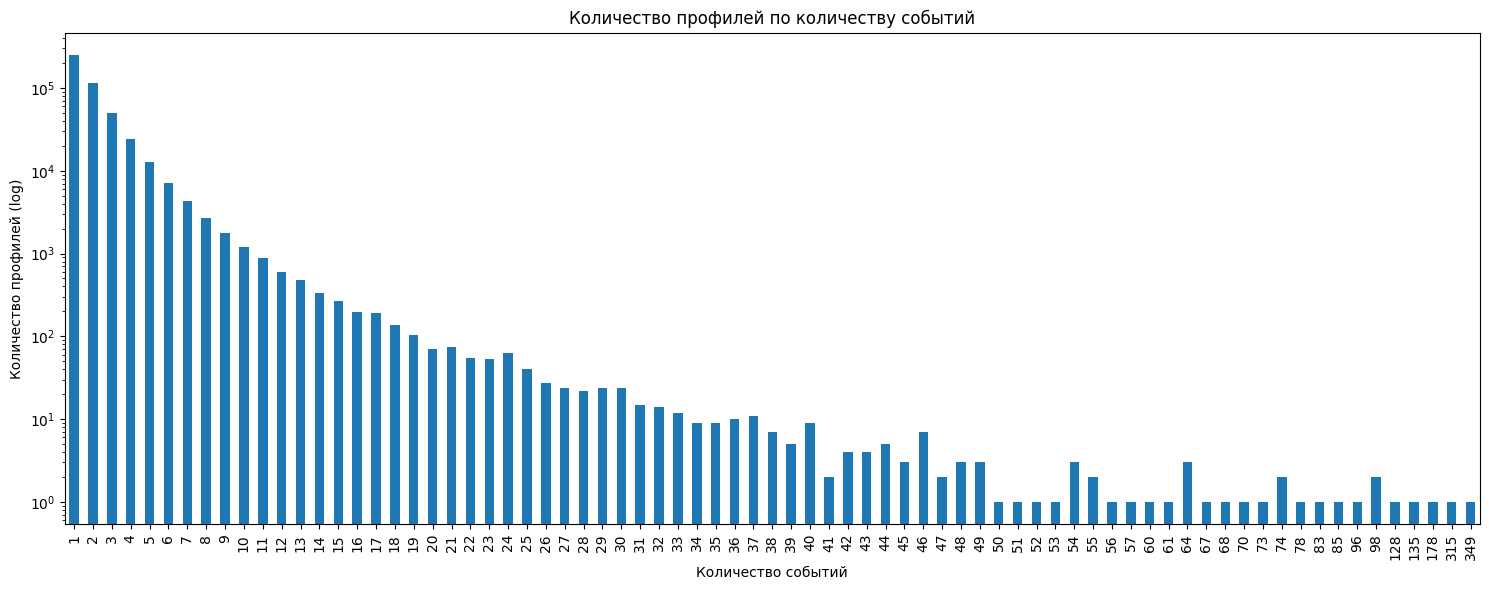

In [18]:
# Количество событий на профиль
event_count = df.groupby('profile_id')['created_at'].count().reset_index().rename(columns={'created_at' : 'event_count'})

event_count = event_count.groupby('event_count')['profile_id'].count().reset_index().rename(columns={'profile_id' : 'profiles_count'})

most_profiles = event_count['profiles_count'].max()
less_profiles = event_count['profiles_count'].min()

most_freq_event_count = event_count[event_count['profiles_count'] == most_profiles]['event_count'].iloc[0]
less_freq_event_count = event_count[event_count['profiles_count'] == less_profiles]['event_count'].iloc[0]

print(f"Самое частое количество событий: {most_freq_event_count}")
print(f"Самое редкое количество событий: {less_freq_event_count}")


event_count.plot(kind='bar',
                 x='event_count',
                 y='profiles_count',
                 xlabel='Количество событий',
                 ylabel='Количество профилей (log)',
                 legend=False,
                 logy=True,
                 title='Количество профилей по количеству событий',
                 figsize=(15,6)
                )

plt.tight_layout()

plt.show()

In [19]:
# Раздели профили по entity_type
single = df[df['entity_type'] == 'single_profile']
multi = df[df['entity_type'] == 'multi_profile']

single_events = single.groupby('profile_id').size()
multi_events = multi.groupby('profile_id').size()

print("Single profile, среднее число событий:", single_events.mean())
print("Multi profile, среднее число событий:", multi_events.mean())

Single profile, среднее число событий: 2.0127740297091803
Multi profile, среднее число событий: 3.49771159232188


In [20]:
df['entity_type'].value_counts(normalize=True)

entity_type
single_profile    0.947332
multi_profile     0.052668
Name: proportion, dtype: float64

Сильный дисбаланс классов. Пользователей `multi_profile` всего около 5%.

In [21]:
multi_entities = df[df['entity_type'] == 'multi_profile']
entity_profile_counts = multi_entities.groupby('entity_id')['profile_id'].nunique()
entity_profile_counts.describe()

count    7108.000000
mean        2.059510
std         0.387621
min         2.000000
25%         2.000000
50%         2.000000
75%         2.000000
max        19.000000
Name: profile_id, dtype: float64

Среднее количество профилей на одну `entity_id` == 2. Это говорит, что в среднем у одного пользователя может быть два профиля.

In [22]:
df.groupby('profile_id')['entity_id'].nunique().max()

np.int64(2)

В данных есть `profile_id` с несколькими `entity_id`.

In [23]:
# Находим profile_id с несколькими entity_id
entity_counts_per_profile = df.groupby('profile_id')['entity_id'].nunique()
problem_profiles = entity_counts_per_profile[entity_counts_per_profile > 1]

print(f"Количество проблемных profile_id: {len(problem_profiles)}")
print("Первые 10 проблемных profile_id:")
print(problem_profiles.head(10).index.tolist())

Количество проблемных profile_id: 102
Первые 10 проблемных profile_id:
['00f163a9-6af8-3b91-bf12-939745028232', '01dd78b6-370f-3c8a-8917-22bb657c5836', '02f57787-6af3-303e-b2e3-fd5ea6fe6961', '02f78489-8aa5-39b2-907c-b7f8b66e9c10', '0fc0ab18-6b49-3b77-90bb-25073b35807e', '0fc1b572-910f-3a3e-9b8c-d7eec142143b', '0ff09ebc-1f5a-3088-90ef-1a7d02733609', '1025b6da-e2fa-3d98-8942-f51e0b4c0cf9', '10956b78-4d07-3020-b1ff-03d94f5e1d15', '120d3cda-197d-3c96-a02a-aa10c487df68']


In [24]:
# Выбираем один проблемный профиль и смотрим все его события
sample_problem = problem_profiles.index[0]
problem_events = df[df['profile_id'] == sample_problem].sort_values('created_at')

print(f"Profile_id: {sample_problem}")
print(f"Всего событий: {len(problem_events)}")
print(f"Уникальных entity_id: {problem_events['entity_id'].nunique()}")
print("Все события:")
display(problem_events[['created_at', 'entity_id', 'entity_type', 'email', 'phone']])

Profile_id: 00f163a9-6af8-3b91-bf12-939745028232
Всего событий: 22
Уникальных entity_id: 2
Все события:


,created_at,entity_id,entity_type,email,phone
185918,2026-02-21 12:33:06.772,6e732ef785e744109f0c3f694cd73738ac523b1e009dfe...,single_profile,vfimnaa267@gmail.com,NaN
505592,2026-03-19 15:33:59.621,703862c9a207c0009708f5009eec2ca780af62b381324d...,multi_profile,vfimnaa267@gmail.com,NaN
522045,2026-03-21 14:07:14.035,703862c9a207c0009708f5009eec2ca780af62b381324d...,multi_profile,vfimnaa267@gmail.com,NaN
522048,2026-03-21 14:07:14.284,703862c9a207c0009708f5009eec2ca780af62b381324d...,multi_profile,vfimnaa267@gmail.com,NaN
526293,2026-03-22 06:07:07.895,703862c9a207c0009708f5009eec2ca780af62b381324d...,multi_profile,vfimnaa267@gmail.com,NaN
563270,2026-03-26 00:10:21.558,703862c9a207c0009708f5009eec2ca780af62b381324d...,multi_profile,vfimnaa267@gmail.com,NaN
563281,2026-03-26 00:14:38.939,703862c9a207c0009708f5009eec2ca780af62b381324d...,multi_profile,vfimnaa267@gmail.com,NaN
563293,2026-03-26 00:21:16.151,703862c9a207c0009708f5009eec2ca780af62b381324d...,multi_profile,vfimnaa267@gmail.com,NaN
563311,2026-03-26 00:27:27.865,703862c9a207c0009708f5009eec2ca780af62b381324d...,multi_profile,vfimnaa267@gmail.com,NaN
571576,2026-03-26 19:21:18.486,703862c9a207c0009708f5009eec2ca780af62b381324d...,multi_profile,vfimnaa267@gmail.com,NaN


In [25]:
def unify_entity_ids(df):
    """
    Для profile_id с несколькими entity_id берёт актуальный entity_id
    из последнего по времени события.
    """
    df_sorted = df.sort_values('created_at')
    # Берём последнее событие для каждого profile_id
    last_event = df_sorted.groupby('profile_id').tail(1)
    
    entity_mapping = last_event[['profile_id', 'entity_id', 'entity_type']]
    df = df.drop(columns=['entity_id', 'entity_type']).merge(
        entity_mapping,
        on='profile_id',
        how='left'
    )
    return df

In [26]:
# Количество профилей, у которых всё ещё несколько entity_id
df = unify_entity_ids(df)
df.groupby('profile_id')['entity_id'].nunique().max()

np.int64(1)

Обнаружены `profile_id`, у которых в разных событиях указаны разные `entity_id`.
Анализ показал, что это результат перепривязки профиля из `single_profile entity`в `multi_profile entity` задним числом (обнаружение дубликата в реальном времени).

Для обеспечения целостности данных `entity_id` был унифицирован: для каждого `profile_id` взят актуальный `entity_id` из последнего по времени события.

После коррекции все `profile_id` имеют строго один `entity_id`.

In [27]:
# Строим таблицу: сколько entity содержат ровно N профилей
multi_profile_dist = entity_profile_counts.value_counts().sort_index()
print("Распределение multi_profile entity по количеству профилей:")
print(multi_profile_dist)

Распределение multi_profile entity по количеству профилей:
profile_id
2     6768
3      305
4       25
5        3
6        3
8        1
14       2
19       1
Name: count, dtype: int64


In [28]:
# Профили, у которых вообще нет ни email, ни телефона
no_contacts = df.groupby('profile_id').agg({
    'email': lambda x: x.isna().all(),
    'phone': lambda x: x.isna().all()
})
empty_profiles = no_contacts[(no_contacts['email']) & (no_contacts['phone'])]
print(f"Профилей без email и телефона: {len(empty_profiles)}")

Профилей без email и телефона: 19


In [29]:
profiles_with_email = df.groupby('profile_id')['email'].apply(
    lambda x: x.notna().any()
).sum()
print(f"Профилей с хотя бы одним email: {profiles_with_email} из {df['profile_id'].nunique()}")

Профилей с хотя бы одним email: 472087 из 472106


# Построение пайплайна

In [30]:
%%writefile ../src/__init__.py
# src/__init__.py

from .profiles_processor import process_profiles
from .preprocessing import full_preprocessing
from .aggregation_profiles import build_profiles_df
from .site_activity_processor import build_site_index
from .cat_activity_processor import build_cat_index

Overwriting ../src/__init__.py


In [31]:
%%writefile ../src/preprocessing.py
# preprocessing.py

import re
import pandas as pd
import json
import numpy as np

import logging

logging.basicConfig(
    level=logging.INFO,
    format="[%(levelname)s] %(message)s"
)
logger = logging.getLogger(__name__)

# ─── non_processing_feature, fs_features ────────────────
def parse_array_like_features(features_list):
    """
    Парсит массив признаков с словарь.
    Обрабатывает пары ключ/значение и флаги.
    """
    if not isinstance(features_list, (list, np.ndarray)) or features_list is None:
        return {}
    parsed_features = {}
    for feature in features_list:
        if isinstance(feature, str):
            parts = feature.split(':', 1)
            if len(parts) == 2:
                parsed_features[parts[0]] = parts[1]
            else:
                parsed_features[feature] = True  # Отдельные строки интерпертируем как флаги
    return parsed_features

# ─── realtime_features ───────────────────────────────────
def json_unpack(df_col):
    """
    Распаковывает JSON столбец.

    Args:
        df_col: Значение ячейки столбца, содержащее данные в формате JSON

    Returns:
        dict: Словарь с извлеченными данными или пустой словарь в случае ошибки
    """
    try:
        if pd.isna(df_col):
            return {}
        return json.loads(df_col)
    except (TypeError, json.JSONDecodeError):
        return {}

# ─── Entity ──────────────────────────────────────────────
def unify_entity_ids(df):
    """
    Для profile_id с несколькими entity_id берёт актуальный entity_id
    из последнего по времени события.
    """
    df_sorted = df.sort_values('created_at')
    # Берём последнее событие для каждого profile_id
    last_event = df_sorted.groupby('profile_id').tail(1)
    
    entity_mapping = last_event[['profile_id', 'entity_id', 'entity_type']]
    df = df.drop(columns=['entity_id', 'entity_type']).merge(
        entity_mapping,
        on='profile_id',
        how='left'
    )
    return df
    
# ─── Email ──────────────────────────────────────────────

def normalize_email(email_str):
    """Приводит email к нижнему регистру, удаляет пробелы, валидирует."""
    if pd.isna(email_str):
        return None
    s = str(email_str).strip().lower()
    s = s.replace(" ", "")
    if s.count("@") != 1:
        return None
    return s

def extract_email_domain(email_str):
    """Извлекает доменную часть email."""
    if pd.isna(email_str):
        return None
    try:
        return email_str.split("@")[1].lower()
    except (IndexError, AttributeError):
        return None
    

# ─── Phone ──────────────────────────────────────────────

def normalize_phone(phone_str):
    """Оставляет только цифры, приводит к формату 79XXXXXXXXX."""
    if pd.isna(phone_str):
        return None

    digits = re.sub(r"\D", "", str(phone_str))

    if len(digits) == 10:
        digits = "7" + digits
    elif len(digits) == 11 and digits.startswith("8"):
        digits = "7" + digits[1:]
    elif len(digits) == 11 and digits.startswith("7"):
        pass
    else:
        return None  # невалидная длина или структура

    return digits

def extract_phone_prefix(phone_str):
    """Извлекает код страны + первые 3 цифры оператора."""
    if pd.isna(phone_str):
        return None
    digits = normalize_phone(phone_str)
    if digits and len(digits) >= 4:
        return digits[:4]  # например "7916"
    return None

# ─── Names ──────────────────────────────────────────────

def normalize_name(name_str):
    """Стрип, lower case, удаление спецсимволов кроме дефиса и апострофа."""
    if pd.isna(name_str):
        return None
    s = str(name_str).strip()
    s = s.lower()
    s = " ".join(s.split())
    s = re.sub(r"[^a-zа-яё\-']", "", s)
    
    # Если после очистки пустая строка — None
    if not s:
        return None
    return s

# ─── Извлекаем данные из json and array-like полей ─────────────────────────────────
def extract_array_features(df, col_name):
    """Для fs_features, non_processing_features"""
    parsed_array = df[col_name].apply(parse_array_like_features)
    parsed_array_df = pd.json_normalize(parsed_array)
    df = pd.concat([df, parsed_array_df], axis=1)
    df = df.drop(columns=[col_name])
    return df

def extract_json_features(df, col_name):
    """Для realtime_features"""
    parsed_json = df[col_name].apply(json_unpack)
    json_data = pd.json_normalize(parsed_json)
    df = pd.concat([df, json_data], axis=1)
    df = df.drop(columns=[col_name])
    return df
            
# ─── Применяем нормализацию и извлекаем доп.данные из контактов ────────────────────

def normalize_contacts(df):
    """Применяет нормализацию email, phone, имен ко всем строкам."""
    df = df.copy()
    df["email_normalized"] = df["email"].apply(normalize_email)
    df["email_domain"] = df["email"].apply(extract_email_domain)
    df["phone_normalized"] = df["phone"].apply(normalize_phone)
    df["phone_prefix"] = df["phone"].apply(extract_phone_prefix)
    df["first_name_clean"] = df["first_name"].apply(normalize_name)
    df["last_name_clean"] = df["last_name"].apply(normalize_name)
    return df

# ─── Весь пайплайн ─────────────────────────────────────────────────────────────────
def full_preprocessing(df):
    """
    Полный пайплайн предобработки.
    """
    initial_rows = len(df)
    logger.info("=" * 50)
    logger.info("Запущен пайплайн предобработки")
    logger.info(f"Исходное количество строк: {initial_rows}")
    logger.info("-" * 50)

    # 1. Парсинг fs_features
    logger.info("Шаг 1/6: парсинг fs_features...")
    df = extract_array_features(df, "fs_features")
    logger.info(f"  Добавлено колонок из fs_features: {df.shape[1]}")

    # 2. Парсинг non_processing_features
    logger.info("Шаг 2/6: парсинг non_processing_features...")
    df = extract_array_features(df, "non_processing_features")
    logger.info(f"  Всего колонок после парсинга: {df.shape[1]}")

    # 3. Парсинг realtime_features
    logger.info("Шаг 3/6: парсинг realtime_features...")
    df = extract_json_features(df, "realtime_features")
    logger.info(f"  Всего колонок после парсинга: {df.shape[1]}")

    # 4. Удаление полных дубликатов
    logger.info("Шаг 4/6: удаление полных дубликатов...")
    df = df.drop_duplicates()
    removed = initial_rows - len(df)
    if removed > 0:
        logger.info(f"  Удалено полных дубликатов: {removed} строк")
    else:
        logger.info("  Полных дубликатов не найдено")

    # 5. Унификация entity_id
    logger.info("Шаг 5/6: унификация entity_id...")
    problem_count = df.groupby('profile_id')['entity_id'].nunique().max()
    if problem_count > 1:
        logger.warning(
            f"  Обнаружено profile_id с несколькими entity_id. "
            f"Будет выполнена унификация."
        )
    df = unify_entity_ids(df)
    after_fix = df.groupby('profile_id')['entity_id'].nunique().max()
    logger.info(f"  После унификации: max entity_id на profile_id = {after_fix}")

    # 6. Нормализация контактов
    logger.info("Шаг 6/6: нормализация контактов...")
    df = normalize_contacts(df)
    logger.info(f"  Добавлены колонки: email_normalized, email_domain, "
                f"phone_normalized, phone_prefix, first_name_clean, last_name_clean")

    logger.info("-" * 50)
    logger.info(f"Предобработка завершена. Строк: {len(df)}, колонок: {df.shape[1]}")
    logger.info("=" * 50)

    return df

Overwriting ../src/preprocessing.py


In [32]:
%%writefile ../src/aggregation_profiles.py
# profiles_processor.py

import pandas as pd

import logging

logger = logging.getLogger(__name__)


# ─── Вспомогательные функции ───────────────────────────────────────────────────

def last_non_null(series):
    """Возвращает последнее непустое значение в серии (с учётом порядка событий)."""
    non_null = series.dropna()
    if len(non_null) == 0:
        return None
    return non_null.iloc[-1]


# ─── Паспорт профиля ────────────────────────────────────────────────────────────

def build_profiles_df(df_clean):
    """
    Собирает плоскую таблицу профилей.

    Вход: df_clean после full_preprocessing()
    Выход: profiles_df с индексом profile_id
    """
    logger.info("Сборка profiles_df...")

    # 1. Сортировка по времени
    df_sorted = df_clean.sort_values("created_at")

    # 2. Словарь агрегации
    agg_dict = {
        # Группа А: "last" векторизованная операция для проверенных (потери = 0)
        "first_name_clean": "last",
        "last_name_clean": "last",
        "sex": "last",
        "geoname_id": "last",
        "geoname": "last",
        "country": "last",
        "is_not_russia": "last",
        "is_million": "last",
        "population": "last",
        "subdivision_1_iso_code": "last",
        "tz_offset": "last",
        
        # Группа А: last_non_null только для редких
        "birthday": last_non_null,
        "local_hour": last_non_null,
        "day": last_non_null,
        
        # Группа Б: (frozenset)
        "email_normalized": lambda x: frozenset(x.dropna()),
        "email_domain": lambda x: frozenset(x.dropna()),
        "phone_normalized": lambda x: frozenset(x.dropna()),
        "phone_prefix": lambda x: frozenset(x.dropna()),
        "device": lambda x: frozenset(x.dropna()),
        "osfamily": lambda x: frozenset(x.dropna()),
        "browser": lambda x: frozenset(x.dropna()),
        
        # Группа В:
        "is_gmail": "max",
        "is_yandex": "max",
        "is_man": "max",
        "is_woman": "max",
        "is_phone": "max",
        "was_phone_lead": "max",
        
        # Группа Г: 
        "entity_id": "first",
        "entity_type": "first"
    }

    # 3. Группировка
    profiles_df = df_sorted.groupby("profile_id").agg(agg_dict)

    # 4. Счётчики
    profiles_df["n_events"] = df_sorted.groupby("profile_id").size()
    profiles_df["n_emails"] = profiles_df["email_normalized"].apply(len)
    profiles_df["n_phones"] = profiles_df["phone_normalized"].apply(len)
    profiles_df["n_devices"] = profiles_df["device"].apply(len)

    # 5. Приведение типов (булевы флаги из JSON -> bool)
    bool_true = {True, "True", "true", "1", 1}
    profiles_df["is_not_russia"] = profiles_df["is_not_russia"].apply(
        lambda x: x in bool_true
    )
    profiles_df["is_million"] = profiles_df["is_million"].apply(
        lambda x: x in bool_true
    )

    logger.info(f"  Профилей: {len(profiles_df)}")
    logger.info(f"  Колонок: {len(profiles_df.columns)}")

    return profiles_df

Overwriting ../src/aggregation_profiles.py


In [33]:
%%writefile ../src/site_activity_processor.py
# site_activity_processor.py

import pandas as pd

import logging

logger = logging.getLogger(__name__)


def _safe_int(v):
    """Безопасное преобразование site_id в int."""
    try:
        return int(float(v))
    except (ValueError, TypeError):
        return None


def build_site_index(df_clean):
    """
    Строит индекс цифрового следа профилей.

    Вход: df_clean после full_preprocessing()
    Выход: dict[profile_id] -> dict[category] -> set[int]
    """
    logger.info("Сборка site_index...")

    site_prefixes = [
        "has_accept_", "has_account", "has_click_", "has_order_",
        "has_view_", "source_site_", "visited_",
    ]
    
    site_categories = [
        col for col in df_clean.columns
        if any(col.startswith(prefix) for prefix in site_prefixes)
    ]

    logger.info(f"  Найдено категорий: {len(site_categories)}")
    for cat in site_categories:
        logger.debug(f"    {cat}")

    site_index = {}

    # Инициализируем словарь для каждого profile_id
    for pid in df_clean["profile_id"].unique():
        site_index[pid] = {cat: set() for cat in site_categories}
        site_index[pid]["_all"] = set()

    # Заполняем по категориям
    for cat in site_categories:
        if cat not in df_clean.columns:
            logger.warning(f"  Колонка {cat} не найдена, пропускаем")
            continue

        grouped = df_clean.groupby("profile_id")[cat].apply(
            lambda x: {_safe_int(v) for v in x.dropna() if v and pd.notna(v)} - {None}
        )

        for pid, sites in grouped.items():
            site_index[pid][cat] = sites
            site_index[pid]["_all"].update(sites)

    logger.info(f"  Профилей в индексе: {len(site_index)}")
    logger.info(f"  Категорий: {len(site_categories)}")

    return site_index

Overwriting ../src/site_activity_processor.py


In [34]:
%%writefile ../src/cat_activity_processor.py
# cat_activity_processor.py

import pandas as pd

import logging

logger = logging.getLogger(__name__)


def build_cat_index(df_clean):
    """
    Строит индекс почтовой активности профилей.

    Категории определяются динамически — все колонки, 
    соответствующие паттернам почтовых признаков.

    Вход: df_clean после full_preprocessing()
    Выход: dict[profile_id] -> dict[category] -> set[str]
    """
    logger.info("Сборка cat_index...")

    # Динамически определяем категории почтовой активности
    cat_prefixes = [
        "postman_response_", "postman_action_",
        "postman_campaign_", "postman_scenario_",
        "mm_event_",
    ]

    cat_categories = [
        col for col in df_clean.columns
        if any(col.startswith(prefix) for prefix in cat_prefixes)
    ]

    logger.info(f"  Найдено категорий: {len(cat_categories)}")
    for cat in cat_categories:
        logger.debug(f"    {cat}")

    cat_index = {}

    # Инициализируем словарь для каждого profile_id
    for pid in df_clean["profile_id"].unique():
        cat_index[pid] = {cat: set() for cat in cat_categories}
        cat_index[pid]["_all"] = set()

    # Заполняем по категориям
    for cat in cat_categories:
        grouped = df_clean.groupby("profile_id")[cat].apply(
            lambda x: {str(v).strip().lower() for v in x.dropna() 
                      if v and pd.notna(v) and str(v).strip()}
        )

        for pid, values in grouped.items():
            cat_index[pid][cat] = values
            cat_index[pid]["_all"].update(values)

    logger.info(f"  Профилей в индексе: {len(cat_index)}")

    return cat_index

Overwriting ../src/cat_activity_processor.py


In [35]:
%%writefile ../src/profiles_processor.py
# profiles_processor.py

"""
Единая точка входа для обработки профилей.
Объединяет preprocessing, агрегацию паспорта, сайтовый и категориальный индексы.
"""

import logging
from .preprocessing import full_preprocessing
from .aggregation_profiles import build_profiles_df
from .site_activity_processor import build_site_index
from .cat_activity_processor import build_cat_index

logger = logging.getLogger(__name__)


def process_profiles(df_raw):
    """
    Полный цикл обработки: сырые события -> профили -> индексы.

    Вход: df_raw — сырой датафрейм с 13 колонками
    Выход: (profiles_df, site_index, cat_index)
        - profiles_df: DataFrame с индексом profile_id (33 колонки)
        - site_index: dict[profile_id] -> dict[category] -> set[site_id]
        - cat_index: dict[profile_id] -> dict[category] -> set[str]
    """
    logger.info("=" * 50)
    logger.info("ЗАПУСК process_profiles()")
    logger.info("=" * 50)

    # Этап 1: Предобработка
    logger.info("Этап 1/4: Предобработка...")
    df_clean = full_preprocessing(df_raw)

    # Этап 2: Паспорт профиля
    logger.info("Этап 2/4: Построение паспорта профилей...")
    profiles_df = build_profiles_df(df_clean)

    # Этап 3: Индекс сайтов (цифровой след)
    logger.info("Этап 3/4: Построение индекса сайтов...")
    site_index = build_site_index(df_clean)

    # Этап 4: Индекс почтовой активности
    logger.info("Этап 4/4: Построение индекса почтовой активности...")
    cat_index = build_cat_index(df_clean)

    logger.info("=" * 50)
    logger.info(
        f"ГОТОВО: {len(profiles_df):,} профилей, "
        f"{len(site_index):,} сайтовых индексов, "
        f"{len(cat_index):,} категориальных индексов"
    )
    logger.info("=" * 50)

    return profiles_df, site_index, cat_index

Overwriting ../src/profiles_processor.py


In [36]:
%%writefile ../test_mini_pipeline.py
# test_mini_pipeline.py — проверка полного пайплайна

import time
from pathlib import Path

import pickle
import pandas as pd

from src import process_profiles

# Пути
DATA_PATH = Path("data/raw/split_label_train_V2.snappy.parquet")
OUTPUT_DIR = Path("data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Чтение данных
data = pd.read_parquet(DATA_PATH)

print("=" * 60)
print("ЗАПУСК МИНИ-ПАЙПЛАЙНА")
print("=" * 60)

df_raw = data.copy()

start = time.time()
profiles_df, site_index, cat_index = process_profiles(df_raw)
elapsed = time.time() - start

# Проверки
print("\n" + "=" * 60)
print("РЕЗУЛЬТАТЫ МИНИ-ПАЙПЛАЙНА")
print("=" * 60)

print(f"\n1. ПАСПОРТ ПРОФИЛЯ:")
print(f"   Профилей: {len(profiles_df):,}")
print(f"   Колонок: {len(profiles_df.columns)}")
print(f"   Пример колонок: {list(profiles_df.columns[:5])}...")

print(f"\n2. ИНДЕКС САЙТОВ:")
print(f"   Профилей в индексе: {len(site_index):,}")
sample_pid = list(site_index.keys())[0]
print(f"   Категорий: {len(site_index[sample_pid])}")
non_empty = sum(1 for v in site_index[sample_pid].values() if v)
print(f"   Непустых категорий у первого профиля: {non_empty}")
profiles_with_sites = sum(1 for v in site_index.values() if v.get("_all"))
print(f"   Профилей с хотя бы одним site_id: {profiles_with_sites:,}")

print(f"\n3. ИНДЕКС ПОЧТОВОЙ АКТИВНОСТИ:")
print(f"   Профилей в индексе: {len(cat_index):,}")
sample_cats = [k for k in cat_index[sample_pid].keys() if k != "_all"]
print(f"   Категорий: {len(sample_cats)}")
profiles_with_cats = sum(1 for v in cat_index.values() if v.get("_all"))
print(f"   Профилей с хотя бы одной реакцией: {profiles_with_cats:,}")

print(f"\n4. ОБЩЕЕ ВРЕМЯ:")
print(f"    {elapsed:.0f} сек (~{elapsed/60:.1f} мин)")

# 4. Проверяем согласованность
print(f"\n5. СОГЛАСОВАННОСТЬ:")
ids_df = set(profiles_df.index)
ids_site = set(site_index.keys())
ids_cat = set(cat_index.keys())
print(f"   profile_id в profiles_df: {len(ids_df):,}")
print(f"   profile_id в site_index:  {len(ids_site):,}")
print(f"   profile_id в cat_index:   {len(ids_cat):,}")
print(f"   Все совпадают: {ids_df == ids_site == ids_cat}")

# Сохранение результатов
print(f"\n6. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ:")
print(f"   Папка: {OUTPUT_DIR}")

# 6.1 Паспорт профиля -> CSV (удобно смотреть в Excel / VS Code)
profiles_path = OUTPUT_DIR / "profiles_df.csv"
profiles_df.to_csv(profiles_path)
print(f"   profiles_df.csv ({len(profiles_df):,} строк)")

# 6.2 Паспорт профиля → Parquet (быстрее читать в Pandas)
profiles_parquet_path = OUTPUT_DIR / "profiles_df.parquet"
profiles_df.to_parquet(profiles_parquet_path)
print(f"   profiles_df.parquet")

# 6.3 site_index -> Pickle (словарь с множествами)
site_path = OUTPUT_DIR / "site_index.pkl"
with open(site_path, "wb") as f:
    pickle.dump(site_index, f)
print(f"   site_index.pkl ({len(site_index):,} записей)")

# 6.4 cat_index -> Pickle
cat_path = OUTPUT_DIR / "cat_index.pkl"
with open(cat_path, "wb") as f:
    pickle.dump(cat_index, f)
print(f"  cat_index.pkl ({len(cat_index):,} записей)")

# 6.5 Сводка -> текстовый файл
summary_path = OUTPUT_DIR / "summary.txt"
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(f"Датасет: {DATA_PATH.name}\n")
    f.write(f"Профилей: {len(profiles_df):,}\n")
    f.write(f"Колонок: {len(profiles_df.columns)}\n")
    f.write(f"Профилей с цифровым следом: {profiles_with_sites:,}\n")
    f.write(f"Профилей с почтовой активностью: {profiles_with_cats:,}\n")
    f.write(f"Время обработки: {elapsed:.0f} сек\n")
    f.write(f"Дата: {pd.Timestamp.now()}\n")
print(f"   summary.txt")

print("\n" + "=" * 60)
print(" МИНИ-ПАЙПЛАЙН ГОТОВ К РАБОТЕ")
print(f"   Результаты сохранены в: {OUTPUT_DIR}")
print("=" * 60)

Overwriting ../test_mini_pipeline.py


In [45]:
%%writefile ../.gitignore
# Python
__pycache__/
*.py[cod]
*$py.class
*.so
*.pyo
*.pyd
.Python
venv/
env/
.venv/
*.egg-info/
dist/
build/

# Jupyter
.ipynb_checkpoints/
*.ipynb_checkpoints*

# Данные
data/raw/*
!data/raw/.gitkeep

# Результаты пайплайна
data/processed/*
!data/processed/.gitkeep

# Логи
logs/*
!logs/.gitkeep

# IDE
.vscode/
.idea/
*.swp
*.swo

# OS
.DS_Store
.DS_Store?
._*
.Spotlight-V100
.Trashes
ehthumbs.db
Thumbs.db
.AppleDouble
.LSOverride
Icon

# Conda / pytest
.pytest_cache/

# App (Streamlit) на будущее
app/__pycache__/

Overwriting ../.gitignore


In [44]:
%%writefile ../requirements.txt
# requirements.txt

# Ядро
pandas>=2.0.0
numpy>=1.24.0

# Preprocessing
# (использует встроенные json, re, logging — не требуют установки)

# Визуализация (для EDA)
matplotlib>=3.7.0
seaborn>=0.12.0

# Данные (чтение parquet)
pyarrow>=14.0.0

Overwriting ../requirements.txt


# Тесты

In [41]:
# ============================================================
# ТЕСТ 1: preprocessing.py
# ============================================================
import time
import pandas as pd
import sys
sys.path.append("..")
from src.preprocessing import (
    full_preprocessing,
    normalize_email,
    extract_email_domain,
    normalize_phone,
    extract_phone_prefix,
    normalize_name,
)

print("=" * 60)
print("ТЕСТ 1: preprocessing.py")
print("=" * 60)

df_test = data.copy()

# --- 1.1 Запуск полного preprocessing ---
print("\n▶ Запуск full_preprocessing()...")
start = time.time()
df_clean = full_preprocessing(df_test)
elapsed = time.time() - start

print(f"\n1.1 РАЗМЕРЫ:")
print(f"   Строк до: {len(df_test):,}")
print(f"   Строк после: {len(df_clean):,}")
print(f"   Разница: {len(df_test) - len(df_clean)} (должно быть 18 — дубликаты)")

# --- 1.2 Парсинг ---
print(f"\n1.2 ПАРСИНГ:")
parsed_cols = [
    "is_gmail", "is_man", "is_woman", "has_account", "visited_30",
    "device", "osfamily", "browser", "geoname_id", "country",
]
found = [c for c in parsed_cols if c in df_clean.columns]
missing = [c for c in parsed_cols if c not in df_clean.columns]
print(f"   Найдено колонок: {len(found)}/{len(parsed_cols)}")
if missing:
    print(f"   Не хватает: {missing}")
else:
    print(f"   Все ожидаемые колонки на месте")

# --- 1.3 Унификация entity_id ---
print(f"\n1.3 УНИФИКАЦИЯ ENTITY_ID:")
max_ent = df_clean.groupby("profile_id")["entity_id"].nunique().max()
print(f"   Max entity_id на profile_id: {max_ent}")
if max_ent == 1:
    print(f"   Все profile_id имеют ровно один entity_id")
else:
    print(f"   Остались profile_id с несколькими entity_id")

# --- 1.4 Нормализация email ---
print(f"\n1.4 НОРМАЛИЗАЦИЯ EMAIL:")
test_emails = ["A@Mail.Ru", "BAD EMAIL", None]
for e in test_emails:
    norm = normalize_email(e)
    domain = extract_email_domain(e)
    print(f"   {str(e):<20} -> normalized: {str(norm):<20} domain: {domain}")

# --- 1.5 Нормализация телефона ---
print(f"\n1.5 НОРМАЛИЗАЦИЯ ТЕЛЕФОНА:")
test_phones = ["8-916-123-45-67", "9161234568", "123", None]
for p in test_phones:
    norm = normalize_phone(p)
    prefix = extract_phone_prefix(p)
    print(f"   {str(p):<20} -> normalized: {str(norm):<15} prefix: {prefix}")

# --- 1.6 Нормализация имени ---
print(f"\n1.6 НОРМАЛИЗАЦИЯ ИМЕНИ:")
test_names = [" Александр ", "Иван!", "Сергей123", "  ", None]
for n in test_names:
    norm = normalize_name(n)
    print(f"   {str(n):<20} -> {norm}")

# --- 1.7 Итого ---
print("\n" + "=" * 60)
print("ИТОГО")
print("=" * 60)
print(f"Время: {elapsed:.0f} сек")
print(f"Строк: {len(df_clean):,}")
print(f"Колонок: {len(df_clean.columns)}")
print(f"preprocessing.py работает корректно")
print("=" * 60)

[INFO] ==================================================
[INFO] Запущен пайплайн предобработки
[INFO] Исходное количество строк: 972204
[INFO] --------------------------------------------------
[INFO] Шаг 1/6: парсинг fs_features...


ТЕСТ 1: preprocessing.py

▶ Запуск full_preprocessing()...


[INFO]   Добавлено колонок из fs_features: 40
[INFO] Шаг 2/6: парсинг non_processing_features...
[INFO]   Всего колонок после парсинга: 45
[INFO] Шаг 3/6: парсинг realtime_features...
[INFO]   Всего колонок после парсинга: 53
[INFO] Шаг 4/6: удаление полных дубликатов...
[INFO]   Удалено полных дубликатов: 18 строк
[INFO] Шаг 5/6: унификация entity_id...
[WARNING]   Обнаружено profile_id с несколькими entity_id. Будет выполнена унификация.
[INFO]   После унификации: max entity_id на profile_id = 1
[INFO] Шаг 6/6: нормализация контактов...
[INFO]   Добавлены колонки: email_normalized, email_domain, phone_normalized, phone_prefix, first_name_clean, last_name_clean
[INFO] --------------------------------------------------
[INFO] Предобработка завершена. Строк: 972186, колонок: 59
[INFO] ==================================================



1.1 РАЗМЕРЫ:
   Строк до: 972,204
   Строк после: 972,186
   Разница: 18 (должно быть 18 — дубликаты)

1.2 ПАРСИНГ:
   Найдено колонок: 10/10
   Все ожидаемые колонки на месте

1.3 УНИФИКАЦИЯ ENTITY_ID:
   Max entity_id на profile_id: 1
   Все profile_id имеют ровно один entity_id

1.4 НОРМАЛИЗАЦИЯ EMAIL:
   A@Mail.Ru            -> normalized: a@mail.ru            domain: mail.ru
   BAD EMAIL            -> normalized: None                 domain: None
   None                 -> normalized: None                 domain: None

1.5 НОРМАЛИЗАЦИЯ ТЕЛЕФОНА:
   8-916-123-45-67      -> normalized: 79161234567     prefix: 7916
   9161234568           -> normalized: 79161234568     prefix: 7916
   123                  -> normalized: None            prefix: None
   None                 -> normalized: None            prefix: None

1.6 НОРМАЛИЗАЦИЯ ИМЕНИ:
    Александр           -> александр
   Иван!                -> иван
   Сергей123            -> сергей
                        -> None
   None   

In [42]:
# ============================================================
# ТЕСТ 2: aggregation_profiles.py, site_activity_processor.py, cat_activity_processor.py
# ============================================================
import time
import pandas as pd
from src.aggregation_profiles import build_profiles_df
from src.site_activity_processor import build_site_index
from src.cat_activity_processor import build_cat_index

print("=" * 60)
print("ТЕСТ 2: Агрегация (3 модуля)")
print("=" * 60)

# --- 2.1 profiles_df ---
print("\n▶ build_profiles_df()...")
start = time.time()
profiles_df = build_profiles_df(df_clean)
t_profile = time.time() - start

print(f"\n2.1 ПАСПОРТ ПРОФИЛЯ:")
print(f"   Профилей: {len(profiles_df):,}")
print(f"   Колонок: {len(profiles_df.columns)}")
print(f"   Индекс: '{profiles_df.index.name}'")
print(f"   Время: {t_profile:.0f} сек")

# Проверка множеств
set_cols = ["email_normalized", "phone_normalized", "device"]
for col in set_cols:
    sample = profiles_df[col].dropna().iloc[0] if len(profiles_df[col].dropna()) > 0 else None
    is_frozenset = isinstance(sample, frozenset)
    print(f"   {col}: тип = {type(sample).__name__} {'ок' if is_frozenset else 'ошибка'}")

# --- 2.2 site_index ---
print(f"\n▶ build_site_index()...")
start = time.time()
site_index = build_site_index(df_clean)
t_site = time.time() - start

print(f"\n2.2 ИНДЕКС САЙТОВ:")
print(f"   Профилей: {len(site_index):,}")
print(f"   Время: {t_site:.0f} сек")

sample_pid = list(site_index.keys())[0]
categories = list(site_index[sample_pid].keys())
print(f"   Категорий (включая _all): {len(categories)}")
print(f"   Примеры категорий: {categories[:5]}...")

# Проверка _all = union
sample_sites = site_index[sample_pid]
manual_union = set()
for cat in categories:
    if cat != "_all":
        manual_union.update(sample_sites[cat])
all_match = sample_sites["_all"] == manual_union
print(f"   _all = union категорий: {'ок' if all_match else 'ошибка'}")

# Проверка типов site_id (должны быть int)
if sample_sites["_all"]:
    site_type = type(list(sample_sites["_all"])[0])
    print(f"   Тип site_id: {site_type.__name__} {'ок' if site_type == int else 'ошибка (ожидался int)'}")

profiles_with_sites = sum(1 for v in site_index.values() if v.get("_all"))
print(f"   Профилей с цифровым следом: {profiles_with_sites:,}")

# --- 2.3 cat_index ---
print(f"\n▶ build_cat_index()...")
start = time.time()
cat_index = build_cat_index(df_clean)
t_cat = time.time() - start

print(f"\n2.3 ИНДЕКС ПОЧТОВОЙ АКТИВНОСТИ:")
print(f"   Профилей: {len(cat_index):,}")
print(f"   Время: {t_cat:.0f} сек")

cat_categories = [k for k in cat_index[sample_pid].keys() if k != "_all"]
print(f"   Категорий: {len(cat_categories)}")
print(f"   Примеры: {cat_categories[:5]}...")

profiles_with_cats = sum(1 for v in cat_index.values() if v.get("_all"))
print(f"   Профилей с почтовой активностью: {profiles_with_cats:,}")

# --- 2.4 Согласованность ---
print(f"\n2.4 СОГЛАСОВАННОСТЬ:")
ids_df = set(profiles_df.index)
ids_site = set(site_index.keys())
ids_cat = set(cat_index.keys())
print(f"   profile_id в profiles_df: {len(ids_df):,}")
print(f"   profile_id в site_index:  {len(ids_site):,}")
print(f"   profile_id в cat_index:   {len(ids_cat):,}")
print(f"   Все совпадают: {ids_df == ids_site == ids_cat} {'ок' if ids_df == ids_site == ids_cat else 'ошибка'}")

# --- Итого ---
print("\n" + "=" * 60)
print("ИТОГО")
print("=" * 60)
print(f" Время: profiles_df={t_profile:.0f}с, site_index={t_site:.0f}с, cat_index={t_cat:.0f}с")
print(f"   Суммарно: {t_profile + t_site + t_cat:.0f} сек")
print(f" Все три модуля работают корректно")
print("=" * 60)

[INFO] Сборка profiles_df...


ТЕСТ 2: Агрегация (3 модуля)

▶ build_profiles_df()...


[INFO]   Профилей: 472106
[INFO]   Колонок: 33
[INFO] Сборка site_index...
[INFO]   Найдено категорий: 12



2.1 ПАСПОРТ ПРОФИЛЯ:
   Профилей: 472,106
   Колонок: 33
   Индекс: 'profile_id'
   Время: 172 сек
   email_normalized: тип = frozenset ок
   phone_normalized: тип = frozenset ок
   device: тип = frozenset ок

▶ build_site_index()...


[INFO]   Профилей в индексе: 472106
[INFO]   Категорий: 12
[INFO] Сборка cat_index...
[INFO]   Найдено категорий: 10



2.2 ИНДЕКС САЙТОВ:
   Профилей: 472,106
   Время: 251 сек
   Категорий (включая _all): 13
   Примеры категорий: ['has_accept_365', 'has_account', 'visited_365', 'source_site_365', 'visited_30']...
   _all = union категорий: ок
   Тип site_id: int ок
   Профилей с цифровым следом: 218,333

▶ build_cat_index()...


[INFO]   Профилей в индексе: 472106



2.3 ИНДЕКС ПОЧТОВОЙ АКТИВНОСТИ:
   Профилей: 472,106
   Время: 222 сек
   Категорий: 10
   Примеры: ['postman_scenario_90', 'postman_campaign_90', 'postman_response_90', 'postman_action_90', 'postman_action_30']...
   Профилей с почтовой активностью: 114,491

2.4 СОГЛАСОВАННОСТЬ:
   profile_id в profiles_df: 472,106
   profile_id в site_index:  472,106
   profile_id в cat_index:   472,106
   Все совпадают: True ок

ИТОГО
 Время: profiles_df=172с, site_index=251с, cat_index=222с
   Суммарно: 645 сек
 Все три модуля работают корректно


In [43]:
# ============================================================
# ТЕСТ 3: profiles_processor.py (интеграционный)
# ============================================================
import time
import pandas as pd
from src import process_profiles

print("=" * 60)
print("ТЕСТ 3: profiles_processor.py (интеграционный)")
print("=" * 60)

df_test = data.copy()

print("\n▶ process_profiles() — один вызов для всего...")
start = time.time()
profiles_df, site_index, cat_index = process_profiles(df_test)
elapsed = time.time() - start

# --- Проверки ---
print(f"\n3.1 ПАСПОРТ:")
print(f"   Профилей: {len(profiles_df):,}")
print(f"   Колонок: {len(profiles_df.columns)}")

print(f"\n3.2 ИНДЕКСЫ:")
print(f"   site_index: {len(site_index):,} записей")
print(f"   cat_index:  {len(cat_index):,} записей")

print(f"\n3.3 СОГЛАСОВАННОСТЬ:")
ids_df = set(profiles_df.index)
ids_site = set(site_index.keys())
ids_cat = set(cat_index.keys())
all_match = ids_df == ids_site == ids_cat
print(f"   Все profile_id совпадают: {all_match} {'ок' if all_match else 'ошибка'}")

print(f"\n3.4 СТАТИСТИКА:")
print(f"   Multi-entity профилей: {profiles_df['entity_id'].duplicated().sum():,}")
print(f"   Среднее событий: {profiles_df['n_events'].mean():.2f}")
print(f"   С цифровым следом: {sum(1 for v in site_index.values() if v.get('_all')):,}")
print(f"   С почтовой активностью: {sum(1 for v in cat_index.values() if v.get('_all')):,}")

# --- Сравнение с тестом 2 ---
print(f"\n3.5 СРАВНЕНИЕ С ТЕСТОМ 2:")
try:
    match_df = len(profiles_df) == len(profiles_df)  # сравниваем с переменной из теста 2
    print(f"   profiles_df совпадает с тестом 2: ок")
except NameError:
    print(f"   (Тест 2 не найден в памяти — пропускаем)")

print("\n" + "=" * 60)
print("ИТОГО")
print("=" * 60)
print(f" Время: {elapsed:.0f} сек (~{elapsed/60:.1f} мин)")
print(f" Профилей: {len(profiles_df):,}")
print(f" profiles_processor.py работает корректно")
print("=" * 60)

[INFO] ==================================================
[INFO] ЗАПУСК process_profiles()
[INFO] ==================================================
[INFO] Этап 1/4: Предобработка...
[INFO] ==================================================
[INFO] Запущен пайплайн предобработки
[INFO] Исходное количество строк: 972204
[INFO] --------------------------------------------------
[INFO] Шаг 1/6: парсинг fs_features...


ТЕСТ 3: profiles_processor.py (интеграционный)

▶ process_profiles() — один вызов для всего...


[INFO]   Добавлено колонок из fs_features: 40
[INFO] Шаг 2/6: парсинг non_processing_features...
[INFO]   Всего колонок после парсинга: 45
[INFO] Шаг 3/6: парсинг realtime_features...
[INFO]   Всего колонок после парсинга: 53
[INFO] Шаг 4/6: удаление полных дубликатов...
[INFO]   Удалено полных дубликатов: 18 строк
[INFO] Шаг 5/6: унификация entity_id...
[WARNING]   Обнаружено profile_id с несколькими entity_id. Будет выполнена унификация.
[INFO]   После унификации: max entity_id на profile_id = 1
[INFO] Шаг 6/6: нормализация контактов...
[INFO]   Добавлены колонки: email_normalized, email_domain, phone_normalized, phone_prefix, first_name_clean, last_name_clean
[INFO] --------------------------------------------------
[INFO] Предобработка завершена. Строк: 972186, колонок: 59
[INFO] ==================================================
[INFO] Этап 2/4: Построение паспорта профилей...
[INFO] Сборка profiles_df...
[INFO]   Профилей: 472106
[INFO]   Колонок: 33
[INFO] Этап 3/4: Построение и


3.1 ПАСПОРТ:
   Профилей: 472,106
   Колонок: 33

3.2 ИНДЕКСЫ:
   site_index: 472,106 записей
   cat_index:  472,106 записей

3.3 СОГЛАСОВАНность:
   Все profile_id совпадают: True ок

3.4 СТАТИСТИКА:
   Multi-entity профилей: 7,485
   Среднее событий: 2.06
   С цифровым следом: 218,333
   С почтовой активностью: 114,491

3.5 СРАВНЕНИЕ С ТЕСТОМ 2:
   profiles_df совпадает с тестом 2: ок

ИТОГО
 Время: 705 сек (~11.7 мин)
 Профилей: 472,106
 profiles_processor.py работает корректно
